In [3]:
!pip install -q datasets transformers

In [4]:
from datasets import load_dataset
ds_train = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='train')
ds_test  = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='test')
print(ds_train)
print(ds_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 5876
})
Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 1476
})


In [5]:
from transformers import CLIPModel, CLIPProcessor
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').eval()
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [6]:
import numpy as np
y_train=np.array(ds_train['label'])
y_test=np.array(ds_test['label'])
print('train:', len(y_train), 'test:', len(y_test))
print('train label counts:', np.bincount(y_train))
print('test  label counts:', np.bincount(y_test))
print('test positive fraction:', y_test.mean())     #low mean suggests mostly are 0

train: 5876 test: 1476
train label counts: [5482  394]
test  label counts: [1372  104]
test positive fraction: 0.07046070460704607


In [9]:
pos=[i for i,y in enumerate(ds_test['label']) if y==1]
neg=[i for i,y in enumerate(ds_test['label']) if y==0]
print(pos[:4])

[0, 1, 2, 3]


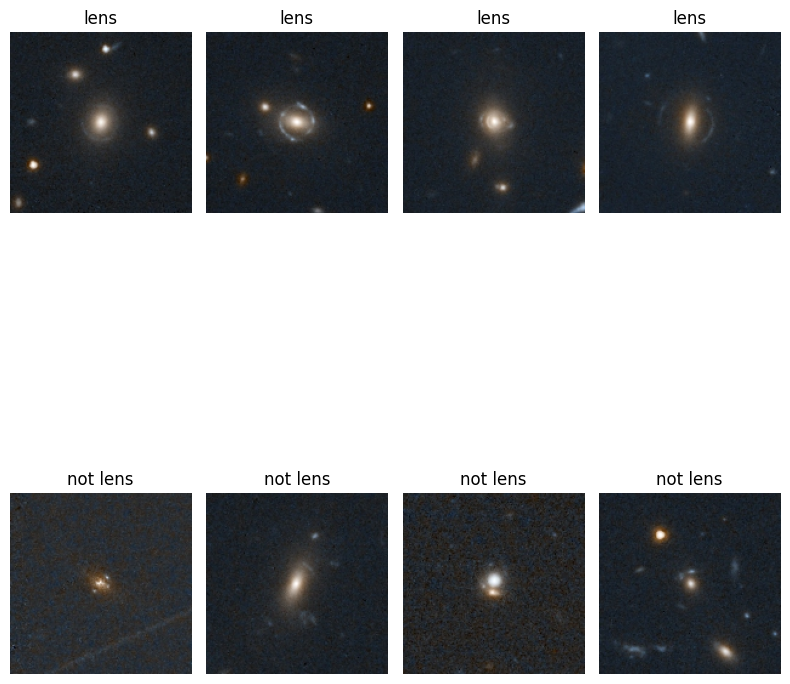

In [10]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(2,4,figsize=(8,12))
for ax, i in zip(axes[0], pos[:4]):
    ax.imshow(ds_test[i]['image']); ax.set_title('lens'); ax.axis('off')
for ax, i in zip(axes[1], neg[:4]):
    ax.imshow(ds_test[i]['image']); ax.set_title('not lens'); ax.axis('off')
plt.tight_layout(); plt.show()

In [11]:
lens_p=[
    'a strong gravitational lens with einstein ring',
    'a gravitaional lens arc next to a galaxy',
    'multiple images of background source due to gravitaional lensing'
]

non_lens_p=[
    'a normal galaxy without gravitational lensing',
    'a spiral galaxy with curved arms but no gravitaional lens arc',
    'a smooth elliptical galaxy with no lensing features'
]

all_p=non_lens_p+lens_p

import torch.nn.functional as F

text_inputs=processor(text=all_p,return_tensors='pt',padding=True)

import torch
with torch.no_grad():
    text_out=model.get_text_features(**text_inputs)
text_emb = text_out.pooler_output
text_emb=F.normalize(text_emb,dim=-1)
n_lens=len(lens_p)
print(n_lens)
print(model)
print(text_emb.shape)

3
CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-0

In [12]:
images = [ex.convert('RGB') for ex in ds_test['image']]
img_embs = []
batch = 64
for start in range(0, len(images), batch):
    chunk = images[start:start+batch]
    inputs = processor(images=chunk, return_tensors='pt')
    with torch.no_grad():
        out = model.get_image_features(**inputs)
    emb=out.pooler_output
    img_embs.append(F.normalize(emb, dim=-1).cpu())
img_emb = torch.cat(img_embs)                       # (N, D)
print(img_emb.shape)

torch.Size([1476, 512])


In [20]:
images=[ex.convert('L') for ex in ds_test['image']]
img_emb=[]
batch=64
for i in range(0,len(images),batch):
    chunk=images[i:i+batch]
    inputs=processor(images=chunk,return_tensors='pt')
    with torch.no_grad():
        out=model.get_image_features(**inputs)
    emb=out.pooler_output
    img_emb.append(F.normalize(emb,dim=-1))
img_emb=torch.cat(img_emb)
print(img_emb)
print(type(img_emb))
print(img_emb.shape)

tensor([[ 0.0259, -0.0729,  0.0139,  ...,  0.0043, -0.0177,  0.0298],
        [ 0.0219, -0.0682,  0.0174,  ..., -0.0054, -0.0029,  0.0262],
        [ 0.0190, -0.0662,  0.0251,  ...,  0.0248, -0.0129,  0.0228],
        ...,
        [ 0.0112, -0.0150,  0.0330,  ...,  0.0718, -0.0019,  0.0229],
        [ 0.0319, -0.0722,  0.0183,  ...,  0.0172, -0.0183,  0.0168],
        [ 0.0191, -0.0431,  0.0401,  ...,  0.0468,  0.0149,  0.0034]])
<class 'torch.Tensor'>
torch.Size([1476, 512])


In [13]:
sims=img_emb@text_emb.T # take transpose of text_emb
lens_sims=sims[:,:n_lens].mean(dim=1)
non_lens_sims=sims[:,n_lens:].mean(dim=1)

scores=(lens_sims-non_lens_sims).numpy()
print('score range:','(',scores.min(),',',scores.max(),')')

score range: ( -0.023674607 , 0.027195364 )


ROC-AUC: 0.536772538685804


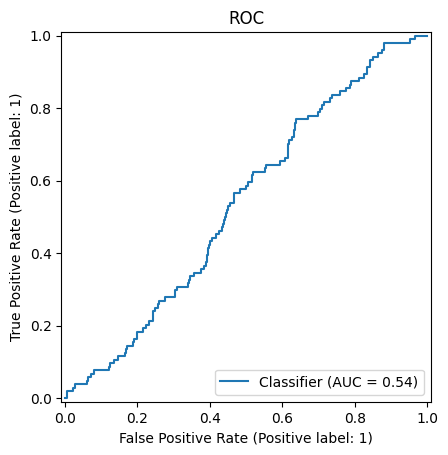

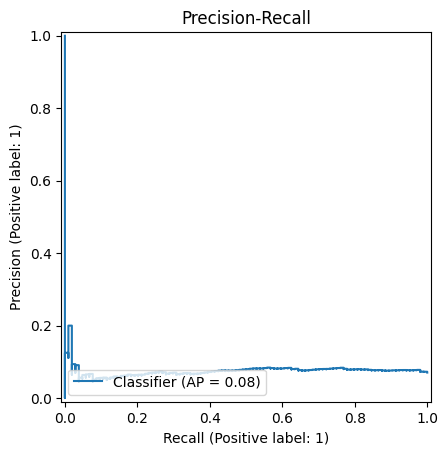

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay 
print('ROC-AUC:', roc_auc_score(y_test, scores))
RocCurveDisplay.from_predictions(y_test, scores)
plt.title('ROC')
plt.show()
PrecisionRecallDisplay.from_predictions(y_test, scores)
plt.title('Precision-Recall')
plt.show()
# Then choose a threshold t and report precision/recall at it, e.g. with classification_report.

In [15]:
order = np.argsort(-scores)                         # high score first
y = np.array(y_test)
top_tp = [i for i in order if y[i] == 1][:4]
worst_fp = [i for i in order if y[i] == 0][:4]
worst_fn = [i for i in order[::-1] if y[i] == 1][:4]
# Plot each row with imshow(ds_test[i]['image']) and a title f"{scores[i]:.3f} / true={y[i]}".